# Importing the required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import seaborn as sb
%matplotlib inline

# Importing the data

In [3]:
db=pd.read_csv('Groundwater.csv')

In [4]:
db.head()

,States,Recharge from rainfallMonsoon season,Recharge from other sources,Recharge from rainfallNon-monsoon season,Recharge from other sources.1,Total_Rainfall,Natural discharge during non-monsoon season,Net annual groundwater availability,Irrigation,Domestic and industrial uses,Total_Usage,Projected demand for domestic and industrial uses upto 2025,Groundwater availability for future irrigation use,Situation
0,Andhra Pradesh,15.1,6.5000,5.5,6.7000,33.8,3.1,30.8,12.600,1.500,14.200,2.70,15.9,EXCESS
1,Arunachal Pradesh,3.4,0.0003,1.0,0.0004,4.5,0.5,4.0,0.002,0.001,0.003,0.01,4.0,SEMICRITICAL
2,Assam,19.0,2.2000,8.6,0.6000,30.4,2.5,27.8,5.300,0.700,6.000,1.00,21.5,EXCESS
3,Bihar,18.9,3.9000,3.4,2.4000,28.6,2.4,26.2,9.800,1.600,11.400,2.60,13.9,MODERATED
4,Chhattisgarh,9.9,0.6000,0.9,0.9000,12.2,0.6,11.6,3.100,0.500,3.600,0.60,7.9,MODERATED


<AxesSubplot:xlabel='Situation', ylabel='count'>

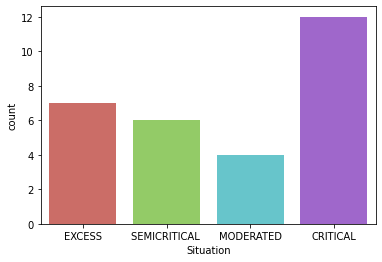

In [5]:
sb.countplot(x='Situation',data=db, palette='hls')

In [6]:
Availabilty = pd.get_dummies(db['Situation'],drop_first=True)
Availabilty.head()

,EXCESS,MODERATED,SEMICRITICAL
0,1,0,0
1,0,0,1
2,1,0,0
3,0,1,0
4,0,1,0


In [7]:
db.drop(['Situation'],axis=1,inplace=True)
db.head()

,States,Recharge from rainfallMonsoon season,Recharge from other sources,Recharge from rainfallNon-monsoon season,Recharge from other sources.1,Total_Rainfall,Natural discharge during non-monsoon season,Net annual groundwater availability,Irrigation,Domestic and industrial uses,Total_Usage,Projected demand for domestic and industrial uses upto 2025,Groundwater availability for future irrigation use
0,Andhra Pradesh,15.1,6.5000,5.5,6.7000,33.8,3.1,30.8,12.600,1.500,14.200,2.70,15.9
1,Arunachal Pradesh,3.4,0.0003,1.0,0.0004,4.5,0.5,4.0,0.002,0.001,0.003,0.01,4.0
2,Assam,19.0,2.2000,8.6,0.6000,30.4,2.5,27.8,5.300,0.700,6.000,1.00,21.5
3,Bihar,18.9,3.9000,3.4,2.4000,28.6,2.4,26.2,9.800,1.600,11.400,2.60,13.9
4,Chhattisgarh,9.9,0.6000,0.9,0.9000,12.2,0.6,11.6,3.100,0.500,3.600,0.60,7.9


In [8]:
new_data = pd.concat([db,Availabilty],axis=1)
new_data.head()

,States,Recharge from rainfallMonsoon season,Recharge from other sources,Recharge from rainfallNon-monsoon season,Recharge from other sources.1,Total_Rainfall,Natural discharge during non-monsoon season,Net annual groundwater availability,Irrigation,Domestic and industrial uses,Total_Usage,Projected demand for domestic and industrial uses upto 2025,Groundwater availability for future irrigation use,EXCESS,MODERATED,SEMICRITICAL
0,Andhra Pradesh,15.1,6.5000,5.5,6.7000,33.8,3.1,30.8,12.600,1.500,14.200,2.70,15.9,1,0,0
1,Arunachal Pradesh,3.4,0.0003,1.0,0.0004,4.5,0.5,4.0,0.002,0.001,0.003,0.01,4.0,0,0,1
2,Assam,19.0,2.2000,8.6,0.6000,30.4,2.5,27.8,5.300,0.700,6.000,1.00,21.5,1,0,0
3,Bihar,18.9,3.9000,3.4,2.4000,28.6,2.4,26.2,9.800,1.600,11.400,2.60,13.9,0,1,0
4,Chhattisgarh,9.9,0.6000,0.9,0.9000,12.2,0.6,11.6,3.100,0.500,3.600,0.60,7.9,0,1,0


In [9]:
X=new_data.iloc[:,[5,6,7,10,11,12]].values
Y=new_data.iloc[:, 13].values

# Preprocessing of data

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.55, random_state = 0)

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
new_data.describe()

,Recharge from rainfallMonsoon season,Recharge from other sources,Recharge from rainfallNon-monsoon season,Recharge from other sources.1,Total_Rainfall,Natural discharge during non-monsoon season,Net annual groundwater availability,Irrigation,Domestic and industrial uses,Total_Usage,Projected demand for domestic and industrial uses upto 2025,Groundwater availability for future irrigation use,EXCESS,MODERATED,SEMICRITICAL
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,8.490690,2.328976,1.563793,2.474152,14.846207,1.210483,13.644483,7.631724,0.758021,8.392048,1.063483,5.292414,0.241379,0.137931,0.206897
std,9.909697,3.420270,2.139700,3.733489,16.931169,1.448532,15.538660,10.802838,0.798408,11.440317,1.172055,7.782267,0.435494,0.350931,0.412251
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.040000,0.000000,0.000200,0.000400,0.001000,-14.600000,0.000000,0.000000,0.000000
25%,1.000000,0.010000,0.200000,0.100000,1.200000,0.100000,1.100000,0.100000,0.030000,0.200000,0.100000,0.400000,0.000000,0.000000,0.000000
50%,4.800000,0.700000,0.800000,0.900000,10.500000,0.600000,9.800000,3.100000,0.700000,3.600000,0.800000,3.000000,0.000000,0.000000,0.000000
75%,12.200000,2.700000,1.900000,3.500000,22.900000,2.000000,20.700000,11.900000,1.100000,13.000000,1.700000,11.900000,0.000000,0.000000,0.000000
max,40.800000,11.400000,8.600000,17.700000,75.300000,6.700000,68.600000,46.000000,3.500000,49.500000,5.400000,21.500000,1.000000,1.000000,1.000000


# GRAPH,PIE CHARTS PLOT

<AxesSubplot:xlabel='EXCESS', ylabel='count'>

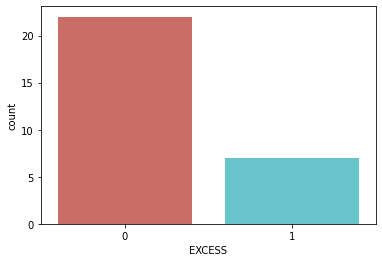

In [13]:
sb.countplot(x='EXCESS',data=new_data, palette='hls')

<AxesSubplot:xlabel='MODERATED', ylabel='count'>

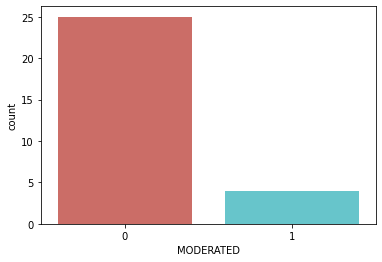

In [14]:
sb.countplot(x='MODERATED',data=new_data, palette='hls')

# Feature Correlation Graphs  Heat Map

<AxesSubplot:>

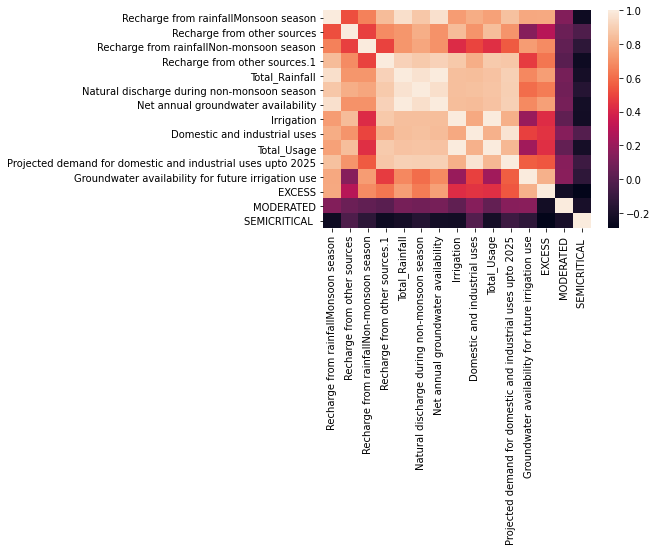

In [15]:
sb.heatmap(new_data.corr())

## PIECHART REPRESENTATION FOR NET ANNUM GROUND WATER

In [16]:
labels='Total Rainfall','Net Annual GroundWater','Total Use','Future Available','Projected demand for domestic and industrial uses upto 2025','Natural discharge during non-monsoon season'
sizes=[14.84,13.64,8.39,5.29,1.063483,1.210483]
cols = ['c','m','r','b','g','y']

([<matplotlib.patches.Wedge at 0x11d19b3f850>,
 [Text(-0.9537411719150084, 0.5480673106418469, 'Total Rainfall'),
  Text(-0.08733339820968328, -1.1065590257899254, 'Net Annual GroundWater'),
  Text(1.1053078027537007, -0.10195421115278551, 'Total Use'),
  Text(0.7113105849433492, 0.8521368738339814, 'Future Available'),
  Text(0.2926496966968201, 1.1637680847244691, 'Projected demand for domestic and industrial uses upto 2025'),
  Text(0.11112363521941154, 1.2952418838563027, 'Natural discharge during non-monsoon season')],
 [Text(-0.5202224574081863, 0.29894580580464375, '33.4%'),
  Text(-0.04799402964676288, -0.6081090141728419, '30.7%'),
  Text(0.6074214051168985, -0.05602889081369293, '18.9%'),
  Text(0.39090041154544414, 0.4682914351700257, '11.9%'),
  Text(0.17071232307314507, 0.6788647160892737, '2.4%'),
  Text(0.06838377551963787, 0.7970719285269554, '2.7%')])

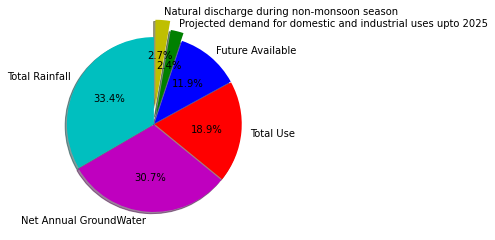

In [17]:
plt.pie(sizes,labels=labels,colors=cols,startangle=90,shadow=True,explode=(0,0.01,0.01,0.01,0.1,0.2),autopct='%1.1f%%')

## PIECHART REPRESENT THE SITUATION IN % 

In [18]:
label='EXCESS','MODERATED','SEMI-CRITICAL','CRITICAL'
sizes=[7,4,6,6]
cols = ['c','m','r','b']

([<matplotlib.patches.Wedge at 0x11d19bb7160>,
 [Text(-0.9150062538795929, 0.6458819980160727, 'EXCESS'),
  Text(-0.700507679540436, -0.8610394827793171, 'MODERATED'),
  Text(0.7005075586159268, -0.8610395811587026, 'SEMI-CRITICAL'),
  Text(0.8185363453415478, 0.76445945043207, 'CRITICAL')],
 [Text(-0.5065213191119174, 0.3575418203303259, '30.4%'),
  Text(-0.3849636797474468, -0.4731838599057508, '17.4%'),
  Text(0.3849636132934372, -0.4731839139700978, '26.1%'),
  Text(0.4531183340283569, 0.4231829100606101, '26.1%')])

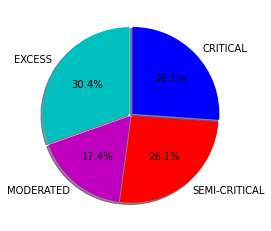

In [19]:
plt.pie(sizes,labels=label,colors=cols,startangle=90,shadow=True,explode=(0.02,0.01,0.01,0.02),autopct='%1.1f%%')



## DISTPLOT IN BTW TOTAL_RAINFALL,NET GROUNDWATER,RECHARGE IN MANSOON SEASON

C:\Users\Ajay\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Ajay\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Ajay\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level 

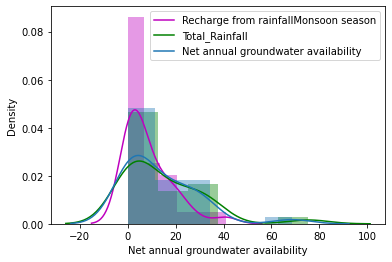

In [20]:
sb.distplot(new_data['Recharge from rainfallMonsoon season'],color='m')
sb.distplot(new_data['Total_Rainfall'],color='g')
sb.distplot(new_data['Net annual groundwater availability'])
plt.legend(['Recharge from rainfallMonsoon season','Total_Rainfall','Net annual groundwater availability'])

C:\Users\Ajay\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Ajay\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


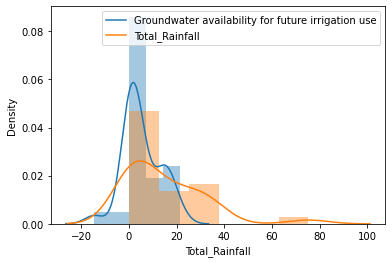

In [21]:
sb.distplot(new_data['Groundwater availability for future irrigation use'])
sb.distplot(new_data['Total_Rainfall'])
plt.legend(['Groundwater availability for future irrigation use','Total_Rainfall'])

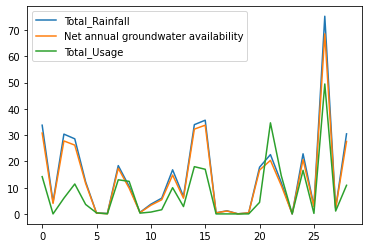

In [22]:
new_data["Total_Rainfall"].plot(kind='line')
new_data["Net annual groundwater availability"].plot()
new_data["Total_Usage"].plot()
plt.legend(['Total_Rainfall','Net annual groundwater availability','Total_Usage'])

# PREDICTING THROUGH DECISION TREE CLASSIFIER

In [23]:
from sklearn.tree import DecisionTreeClassifier

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = .55, random_state=0)

In [25]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_scaled=ss.fit_transform(X)

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled,Y,test_size = 0.33)

In [27]:
tree = DecisionTreeClassifier()
tree.fit(X_train, Y_train)

DecisionTreeClassifier()

In [28]:
tree.feature_importances_

array([1., 0., 0., 0., 0., 0.])

In [29]:
print("accuracy on training set: %f" % tree.score(X_train, Y_train))
print("accuracy on test set: %f" % tree.score(X_test, Y_test))

accuracy on training set: 1.000000
accuracy on test set: 0.900000


In [30]:
tree = DecisionTreeClassifier()
tree.fit(X_train, Y_train)

print("accuracy on training set: %f" % tree.score(X_train, Y_train))
print("accuracy on test set:  %f" % tree.score(X_test, Y_test))

accuracy on training set: 1.000000
accuracy on test set:  0.900000


In [31]:
tree.feature_importances_

array([1., 0., 0., 0., 0., 0.])

In [32]:
features_names = new_data.columns
features_names

Index(['States', 'Recharge from rainfallMonsoon season',
       'Recharge from other sources',
       'Recharge from rainfallNon-monsoon season',
       'Recharge from other sources.1', 'Total_Rainfall',
       'Natural discharge during non-monsoon season',
       'Net annual groundwater availability', 'Irrigation',
       'Domestic and industrial uses', 'Total_Usage',
       'Projected demand for domestic and industrial uses upto 2025',
       'Groundwater availability for future irrigation use', 'EXCESS',
       'MODERATED', 'SEMICRITICAL '],
      dtype='object')

# PREDICTING THROUGH RANDOM FOREST

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [34]:
X=new_data.iloc[:,[5,6,7,10,11,12]].values
y=new_data.iloc[:, 13].values

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.55, random_state=0)

In [36]:
random = RandomForestClassifier()
random.fit(X_train, y_train)

RandomForestClassifier()

In [37]:
print("accuracy on training set: %f" % random.score(X_train, y_train))
print("accuracy on test set: %f" % random.score(X_test, y_test))

accuracy on training set: 1.000000
accuracy on test set: 0.937500


In [38]:
random = RandomForestClassifier(max_leaf_nodes=10)
random.fit(X_train, y_train)

print("accuracy on training set: %f" % random.score(X_train, y_train))
print("accuracy on test set: %f" % random.score(X_test, y_test))

accuracy on training set: 1.000000
accuracy on test set: 0.937500


In [39]:
random = RandomForestClassifier(max_features='auto')
random.fit(X_train, y_train)

print("accuracy on training set: %f" % random.score(X_train, y_train))
print("accuracy on test set: %f" % random.score(X_test, y_test))

accuracy on training set: 1.000000
accuracy on test set: 0.937500


In [40]:
random = RandomForestClassifier(random_state=250)
random.fit(X_train, y_train)

print("accuracy on training set: %f" % random.score(X_train, y_train))
print("accuracy on test set: %f" % random.score(X_test, y_test))

accuracy on training set: 1.000000
accuracy on test set: 0.937500


In [41]:
X

array([[ 3.38e+01,  3.10e+00,  3.08e+01,  1.42e+01,  2.70e+00,  1.59e+01],
       [ 4.50e+00,  5.00e-01,  4.00e+00,  3.00e-03,  1.00e-02,  4.00e+00],
       [ 3.04e+01,  2.50e+00,  2.78e+01,  6.00e+00,  1.00e+00,  2.15e+01],
       [ 2.86e+01,  2.40e+00,  2.62e+01,  1.14e+01,  2.60e+00,  1.39e+01],
       [ 1.22e+01,  6.00e-01,  1.16e+01,  3.60e+00,  6.00e-01,  7.90e+00],
       [ 3.00e-01,  2.00e-02,  3.00e-01,  4.00e-01,  3.00e-01,  1.00e-02],
       [ 2.00e-01,  1.00e-01,  1.00e-01,  4.00e-02,  4.00e-02,  1.00e-01],
       [ 1.84e+01,  1.10e+00,  1.74e+01,  1.30e+01,  1.50e+00,  5.30e+00],
       [ 1.05e+01,  7.00e-01,  9.80e+00,  1.24e+01,  8.00e-01, -2.70e+00],
       [ 6.00e-01,  1.00e-01,  5.00e-01,  3.00e-01,  1.00e-01,  2.00e-01],
       [ 3.70e+00,  4.00e-01,  3.30e+00,  7.00e-01,  8.00e-01,  2.40e+00],
       [ 6.00e+00,  6.00e-01,  5.40e+00,  1.60e+00,  6.00e-01,  3.60e+00],
       [ 1.68e+01,  2.00e+00,  1.48e+01,  1.00e+01,  1.30e+00,  6.20e+00],
       [ 6.60e+00,  6.00e

In [42]:
Y

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1], dtype=uint8)

In [43]:
new_data

,States,Recharge from rainfallMonsoon season,Recharge from other sources,Recharge from rainfallNon-monsoon season,Recharge from other sources.1,Total_Rainfall,Natural discharge during non-monsoon season,Net annual groundwater availability,Irrigation,Domestic and industrial uses,Total_Usage,Projected demand for domestic and industrial uses upto 2025,Groundwater availability for future irrigation use,EXCESS,MODERATED,SEMICRITICAL
0,Andhra Pradesh,15.10,6.5000,5.50,6.7000,33.80,3.100,30.80,12.600,1.5000,14.2000,2.700,15.90,1,0,0
1,Arunachal Pradesh,3.40,0.0003,1.00,0.0004,4.50,0.500,4.00,0.002,0.0010,0.0030,0.010,4.00,0,0,1
2,Assam,19.00,2.2000,8.60,0.6000,30.40,2.500,27.80,5.300,0.7000,6.0000,1.000,21.50,1,0,0
3,Bihar,18.90,3.9000,3.40,2.4000,28.60,2.400,26.20,9.800,1.6000,11.4000,2.600,13.90,0,1,0
4,Chhattisgarh,9.90,0.6000,0.90,0.9000,12.20,0.600,11.60,3.100,0.5000,3.6000,0.600,7.90,0,1,0
5,Delhi,0.10,0.1000,0.02,0.1000,0.30,0.020,0.30,0.100,0.3000,0.4000,0.300,0.01,0,0,0
6,Goa,0.10,0.0100,0.01,0.1000,0.20,0.100,0.10,0.010,0.0300,0.0400,0.040,0.10,0,0,0
7,Gujarat,12.20,2.8000,0.00,3.5000,18.40,1.100,17.40,11.900,1.1000,13.0000,1.500,5.30,0,1,0
8,Haryana,3.50,2.7000,1.00,3.3000,10.50,0.700,9.80,11.700,0.7000,12.4000,0.800,-2.70,0,0,0
9,Himachal Pradesh,0.40,0.0200,0.10,0.0400,0.60,0.100,0.50,0.200,0.1000,0.3000,0.100,0.20,0,0,0


In [117]:
xn=[[16,3.30,22.6,15.05,1.99,1.12]]

In [118]:
yn=[[1]]

In [119]:
xtr=sc.fit_transform(xn)

In [120]:
ytr=sc.fit_transform(yn)

In [121]:
random.score(xtr,ytr)

1.0